Library Installations & Data Cleaning


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
data = pd.read_csv("/content/sample_data/Sales.csv",encoding='latin1')

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order ID                  1000 non-null   int64  
 1   Customer Last Name        1000 non-null   object 
 2   Customer First Name       1000 non-null   object 
 3   Customer ID               1000 non-null   int64  
 4   Service Category          1000 non-null   object 
 5   Order Date                1000 non-null   object 
 6   Quantity Ordered          1000 non-null   int64  
 7   Order Status              1000 non-null   object 
 8   State                     1000 non-null   object 
 9   Margins                   1000 non-null   float64
 10  Service Provider Expense  1000 non-null   float64
 11  Sale Price                1000 non-null   int64  
 12  Total Profit (GMROI)      1000 non-null   float64
 13  Sales Agent               1000 non-null   object 
dtypes: float6

In [58]:
data.head()

,Order ID,Customer Last Name,Customer First Name,Customer ID,Service Category,Order Date,Quantity Ordered,Order Status,State,Margins,Service Provider Expense,Sale Price,Total Profit (GMROI),Sales Agent
0,3001,Hughes,Lewis,1234,Inter Prep,05-06-2024,3,Delivered,WA,0.10,56.40,564,507.60,Kelly
1,3002,Gomez,Ali,1235,Resume + LinkedIn,7/18/2024,3,In Progress,ACT,0.30,233.10,777,543.90,Kelly
2,3003,Beck,Mila,1236,LinkedIn,7/14/2024,1,Delivered,NSW,0.25,457.25,1829,1371.75,Priscilla
3,3004,Juarez,Ryleigh,1237,LinkedIn,6/26/2024,2,Delivered,VIC,0.25,56.75,227,170.25,Daniel
4,3005,Preston,Leonidas,1238,Networking,11/28/2024,1,Service Booked,QLD,0.20,271.00,1355,1084.00,Brian


In [59]:
data.tail()

,Order ID,Customer Last Name,Customer First Name,Customer ID,Service Category,Order Date,Quantity Ordered,Order Status,State,Margins,Service Provider Expense,Sale Price,Total Profit (GMROI),Sales Agent
995,3996,Robbins,Crew,2227,Mentoring,12/14/2024,3,Service Booked,QLD,0.25,466.25,1865,1398.75,Daniel
996,3997,Salinas,Willow,2228,Resume,04-04-2024,2,Cancelled,VIC,0.30,315.00,1050,735.00,Kelly
997,3998,Bond,Malachi,2229,Mentoring,6/24/2024,3,Service Booked,WA,0.25,264.75,1059,794.25,Daniel
998,3999,Willis,Patrick,2230,Mentoring,05-11-2024,3,Service Booked,SA,0.25,279.00,1116,837.00,Priscilla
999,4000,Compton,Dallas,2231,Networking,01-09-2024,2,Delivered,SA,0.20,9.80,49,39.20,Brian


In [60]:
print('No of rows:',data.shape[0])
print('No of columns:',data.shape[1])

No of rows: 1000
No of columns: 14


In [61]:
print(data.isnull().sum())

Order ID                    0
Customer Last Name          0
Customer First Name         0
Customer ID                 0
Service Category            0
Order Date                  0
Quantity Ordered            0
Order Status                0
State                       0
Margins                     0
Service Provider Expense    0
Sale Price                  0
Total Profit (GMROI)        0
Sales Agent                 0
dtype: int64


In [62]:
data.describe()

,Order ID,Customer ID,Quantity Ordered,Margins,Service Provider Expense,Sale Price,Total Profit (GMROI)
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3500.500000,1731.99600,2.010000,0.233050,206.466650,890.427000,683.960350
std,288.819436,288.21378,0.821325,0.064957,136.610881,514.266924,402.355764
min,3001.000000,1234.00000,1.000000,0.100000,1.100000,11.000000,7.700000
25%,3250.750000,1482.75000,1.000000,0.200000,91.325000,431.750000,333.450000
50%,3500.500000,1731.50000,2.000000,0.250000,179.200000,897.000000,679.000000
75%,3750.250000,1981.25000,3.000000,0.300000,309.562500,1311.250000,1013.337500
max,4000.000000,2231.00000,3.000000,0.300000,571.200000,1904.000000,1660.500000


<Axes: xlabel='State', ylabel='count'>

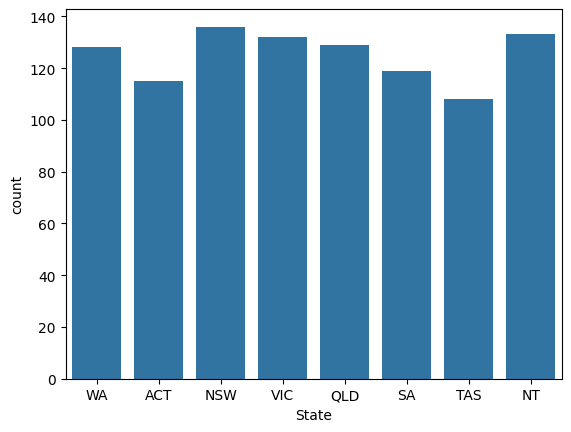

In [63]:
sns.countplot(x=data['State'])

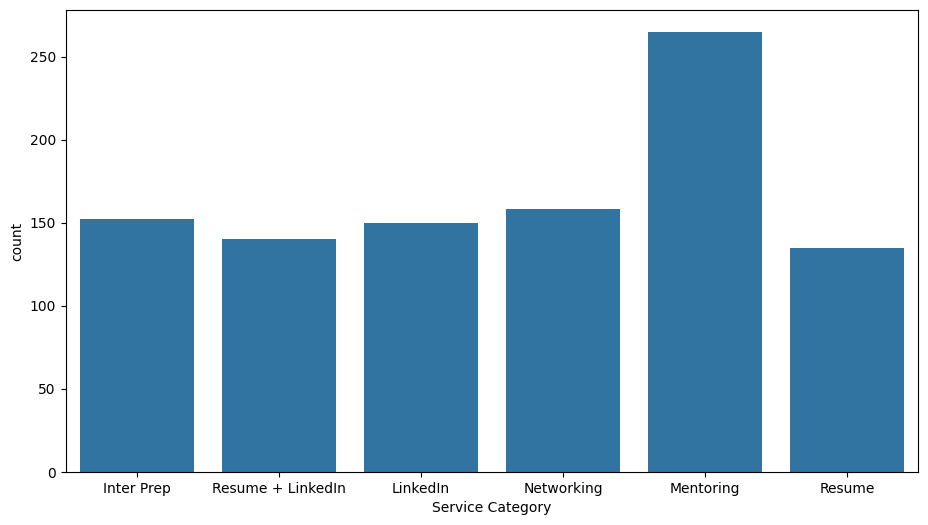

In [80]:
plt.figure(figsize=(11, 6))
sns.countplot(x='Service Category', data=data)
plt.show()

In [65]:
df = data.drop(['Order ID','Customer Last Name','Customer First Name','Customer ID','Order Date'], axis=1)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Service Category          1000 non-null   object 
 1   Quantity Ordered          1000 non-null   int64  
 2   Order Status              1000 non-null   object 
 3   State                     1000 non-null   object 
 4   Margins                   1000 non-null   float64
 5   Service Provider Expense  1000 non-null   float64
 6   Sale Price                1000 non-null   int64  
 7   Total Profit (GMROI)      1000 non-null   float64
 8   Sales Agent               1000 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 70.4+ KB


In [67]:
# One-Hot Encode categorical columns
categorical_cols = ['Service Category','Order Status','State','Sales Agent']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [68]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Quantity Ordered                    1000 non-null   int64  
 1   Margins                             1000 non-null   float64
 2   Service Provider Expense            1000 non-null   float64
 3   Sale Price                          1000 non-null   int64  
 4   Total Profit (GMROI)                1000 non-null   float64
 5   Service Category_LinkedIn           1000 non-null   bool   
 6   Service Category_Mentoring          1000 non-null   bool   
 7   Service Category_Networking         1000 non-null   bool   
 8   Service Category_Resume             1000 non-null   bool   
 9   Service Category_Resume + LinkedIn  1000 non-null   bool   
 10  Order Status_Delivered              1000 non-null   bool   
 11  Order Status_In Progress            1000 non

In [69]:
from sklearn.model_selection import train_test_split


Training and Testing


In [72]:
cols_to_drop = ['Margins', 'Service Provider Expense', 'Sale Price', 'Total Profit (GMROI)']
# Filter out columns that are not actually in df_encoded
existing_cols_to_drop = [col for col in cols_to_drop if col in df_encoded.columns]
X = df_encoded.drop(columns=existing_cols_to_drop, axis=1)

# Target
y = df_encoded['Total Profit (GMROI)']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (800, 21)
X_test shape: (200, 21)
y_train shape: (800,)
y_test shape: (200,)


Linear Regression Model


In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [75]:
# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [76]:
y_pred = lr_model.predict(X_test)


In [77]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Root Mean Squared Error
rmse = mse ** 0.5
print("Root Mean Squared Error (RMSE):", rmse)

# R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared (R2):", r2)


Mean Squared Error (MSE): 1012.620772620771
Root Mean Squared Error (RMSE): 31.8217028554534
R-squared (R2): 0.9934441060052475


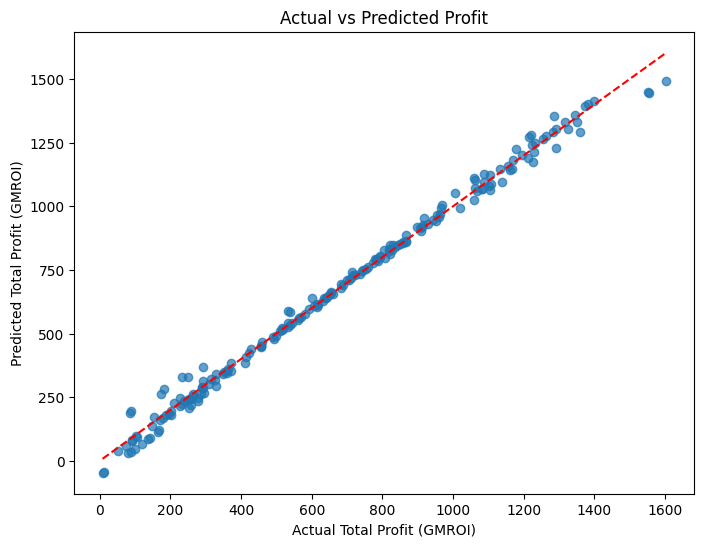

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Total Profit (GMROI)")
plt.ylabel("Predicted Total Profit (GMROI)")
plt.title("Actual vs Predicted Profit")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
plt.show()
